# GAT on Fully Connected Graph vs MLP

This notebook compares Graph Attention Network (GAT) on fully connected graphs with MLP baseline.

- **Node features**: 4 features with Z-score normalization
- **Edge features**: 8 statistical features with log-transform + Z-score normalization  
- **Graph structure**: Fully connected (10 nodes, 55 edges in CSV → 100 edges in DGL)

## Data Loading

In [43]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import dgl
from glob import glob
from sklearn.model_selection import train_test_split

def parse_edge_features(feature_string):
    """Parse edge features from string format [value1\tvalue2\t...]."""
    feature_string = str(feature_string).strip()
    if feature_string.startswith('['):
        feature_string = feature_string[1:]
    if feature_string.endswith(']'):
        feature_string = feature_string[:-1]
    
    values = [float(x.strip()) for x in feature_string.split() if x.strip()]
    return np.array(values)

def calculate_edge_statistics(features_array):
    """Calculate 8 statistics for edge features (without skewness)."""
    return {
        'min': np.min(features_array),
        'q25': np.percentile(features_array, 25),
        'median': np.median(features_array),
        'q75': np.percentile(features_array, 75),
        'max': np.max(features_array),
        'mean': np.mean(features_array),
        'std': np.std(features_array),
        'feature_count': len(features_array)
    }

def load_data(input_folder, num_nodes=10, expected_edges=55):
    """
    Load phylogenetic graph data with node and edge features.
    
    Args:
        input_folder: Path to folder containing CSV files
        num_nodes: Expected number of nodes per graph (default: 10)
        expected_edges: Expected number of edges in CSV (default: 55)
                       This becomes 100 in DGL (10 self-loops + 45*2 bidirectional)
    
    Returns:
        List of DGL graphs with node and edge features
    """
    # Load node files
    node_files = sorted(glob(f"{input_folder}/*_node.csv"))
    all_nodes = pd.concat([pd.read_csv(f) for f in node_files], ignore_index=True)
    
    # Load edge files
    edge_files = sorted(glob(f"{input_folder}/*_edge.csv"))
    all_edges = pd.concat([pd.read_csv(f) for f in edge_files], ignore_index=True)
    
    # Filter valid graph IDs (must have correct number of nodes and edges)
    node_counts = all_nodes.groupby('graph_id').size()
    edge_counts = all_edges.groupby('graph_id').size()
    
    valid_node_ids = set(gid for gid in node_counts.index if node_counts[gid] == num_nodes)
    valid_edge_ids = set(gid for gid in edge_counts.index if edge_counts[gid] == expected_edges)
    valid_ids = sorted(valid_node_ids & valid_edge_ids)
    
    print(f"Graphs with {num_nodes} nodes: {len(valid_node_ids)}")
    print(f"Graphs with {expected_edges} edges: {len(valid_edge_ids)}")
    print(f"Valid graphs (both conditions): {len(valid_ids)}")
    
    # Parse edge features and calculate statistics
    print("\nParsing edge features...")
    all_edges['features_array'] = all_edges['edge_features'].apply(parse_edge_features)
    
    edge_stats_list = []
    for idx, row in all_edges.iterrows():
        stats = calculate_edge_statistics(row['features_array'])
        stats['graph_id'] = row['graph_id']
        stats['node1'] = row['node1']
        stats['node2'] = row['node2']
        edge_stats_list.append(stats)
    
    edge_stats_df = pd.DataFrame(edge_stats_list)
    print(f"Calculated statistics for {len(edge_stats_df)} edges")
    
    # Build graphs
    graphs = []
    for gid in valid_ids:
        # Get node data
        node_df = all_nodes[all_nodes['graph_id'] == gid].sort_values('node').reset_index(drop=True)
        
        # Get edge data
        edge_df = edge_stats_df[edge_stats_df['graph_id'] == gid].reset_index(drop=True)
        
        # Create edge lists for DGL (bidirectional)
        src_nodes = []
        dst_nodes = []
        edge_features = []
        
        for _, row in edge_df.iterrows():
            n1, n2 = int(row['node1']), int(row['node2'])
            
            # Extract edge feature vector (8 features)
            feat_vec = [row['min'], row['q25'], row['median'], row['q75'], row['max'],
                       row['mean'], row['std'], row['feature_count']]
            
            if n1 == n2:  # Self-loop
                src_nodes.append(n1)
                dst_nodes.append(n2)
                edge_features.append(feat_vec)
            else:  # Bidirectional edge
                # n1 -> n2
                src_nodes.append(n1)
                dst_nodes.append(n2)
                edge_features.append(feat_vec)
                
                # n2 -> n1 (same features)
                src_nodes.append(n2)
                dst_nodes.append(n1)
                edge_features.append(feat_vec)
        
        # Create DGL graph
        g = dgl.graph((torch.tensor(src_nodes), torch.tensor(dst_nodes)))
        
        # Add node features (raw, will normalize later)
        for col in node_df.columns:
            if col not in ['graph_id', 'node']:
                g.ndata[col] = torch.tensor(node_df[col].values, dtype=torch.float32)
        
        # Add edge features (raw, will normalize later)
        g.edata['feat_raw'] = torch.tensor(edge_features, dtype=torch.float32)
        
        g.graph_id = gid
        graphs.append(g)
    
    print(f"\nLoaded {len(graphs)} graphs")
    print(f"Each graph: {num_nodes} nodes, {graphs[0].num_edges()} edges in DGL")
    print(f"Node features: {list(node_df.columns[2:])}")
    print(f"Edge features: 8 statistics (min, q25, median, q75, max, mean, std, feature_count)")
    
    return graphs

# Load data
graphs = load_data('/Users/lukelyu/Desktop/epidata/100_10_new/', num_nodes=10, expected_edges=55)

# Define node and edge features
node_features = ['Initial_Population', 'Epidemic_Peak', 'Peak_Timing', 'Accumulated_Infections']
edge_feature_names = ['min', 'q25', 'median', 'q75', 'max', 'mean', 'std', 'feature_count']
label = 'R0'

# Prepare node features and labels
for g in graphs:
    g.ndata['feat'] = torch.stack([g.ndata[name] for name in node_features], dim=1)
    g.ndata['label'] = g.ndata[label]

# Train/val/test split
torch.manual_seed(42)
train_graphs, temp = train_test_split(graphs, test_size=0.3, random_state=42)
val_graphs, test_graphs = train_test_split(temp, test_size=0.5, random_state=42)

print(f"\nSplit: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")

Graphs with 10 nodes: 500
Graphs with 55 edges: 427
Valid graphs (both conditions): 427

Parsing edge features...
Calculated statistics for 26369 edges

Loaded 427 graphs
Each graph: 10 nodes, 100 edges in DGL
Node features: ['Initial_Population', 'R0', 'Epidemic_Peak', 'Peak_Timing', 'Accumulated_Infections', 'Num_Samples', 'Source_Sink_Score']
Edge features: 8 statistics (min, q25, median, q75, max, mean, std, feature_count)

Split: Train=298, Val=64, Test=65


## Feature Normalization

Apply Z-score normalization to both node and edge features (fitted on training data only).

In [44]:
print("="*80)
print("NODE FEATURE NORMALIZATION (Z-score)")
print("="*80)

# Normalize node features
for i, fname in enumerate(node_features):
    train_feat = torch.cat([g.ndata['feat'][:, i] for g in train_graphs])
    mean, std = train_feat.mean(), train_feat.std()
    
    for g in train_graphs + val_graphs + test_graphs:
        g.ndata['feat'][:, i] = (g.ndata['feat'][:, i] - mean) / std
    
    print(f"{fname:30s}: Mean={mean:8.2f}, Std={std:8.2f}")

print("\n" + "="*80)
print("EDGE FEATURE NORMALIZATION (Log-transform + Z-score)")
print("="*80)

# Log-transform feature_count (index 7)
print("\nStep 1: Log-transform feature_count")
for g in train_graphs + val_graphs + test_graphs:
    g.edata['feat_raw'][:, 7] = torch.log1p(g.edata['feat_raw'][:, 7])
print("Applied log1p(feature_count)")

# Z-score normalization on all 9 edge features
print("\nStep 2: Z-score normalization on all edge features")
for i, fname in enumerate(edge_feature_names):
    train_feat = torch.cat([g.edata['feat_raw'][:, i] for g in train_graphs])
    mean, std = train_feat.mean(), train_feat.std()
    
    for g in train_graphs + val_graphs + test_graphs:
        g.edata['feat_raw'][:, i] = (g.edata['feat_raw'][:, i] - mean) / std
    
    fname_display = f"{fname} (log-transformed)" if fname == 'feature_count' else fname
    print(f"{fname_display:30s}: Mean={mean:8.4f}, Std={std:8.4f}")

# Rename edge features from 'feat_raw' to 'feat'
for g in train_graphs + val_graphs + test_graphs:
    g.edata['feat'] = g.edata['feat_raw']
    del g.edata['feat_raw']

print("\n" + "="*80)
print("Normalization complete!")
print(f"Node features: {len(node_features)} dimensions")
print(f"Edge features: {len(edge_feature_names)} dimensions")
print("="*80)

NODE FEATURE NORMALIZATION (Z-score)
Initial_Population            : Mean= 5596.03, Std= 2600.03
Epidemic_Peak                 : Mean= 2214.80, Std= 1022.15
Peak_Timing                   : Mean=  140.19, Std=   38.73
Accumulated_Infections        : Mean= 5932.64, Std= 2485.32

EDGE FEATURE NORMALIZATION (Log-transform + Z-score)

Step 1: Log-transform feature_count
Applied log1p(feature_count)

Step 2: Z-score normalization on all edge features
min                           : Mean=114.2439, Std= 42.4213
q25                           : Mean=226.1960, Std= 49.8433
median                        : Mean=258.8744, Std= 54.7866
q75                           : Mean=293.0940, Std= 60.5817
max                           : Mean=400.2433, Std=101.6796
mean                          : Mean=259.7362, Std= 53.9453
std                           : Mean= 50.8438, Std= 15.2214
feature_count (log-transformed): Mean=  5.6169, Std=  1.1122

Normalization complete!
Node features: 4 dimensions
Edge features: 8 

## Model Definitions

GAT with edge features and MLP baseline.

In [45]:
import torch.nn.functional as F
import dgl.function as fn

class GAT_EdgeOnly(nn.Module):
    """GAT with EDGE-ONLY attention."""
    def __init__(self, in_dim, edge_dim, hidden_dim=32, num_heads=1):
        super().__init__()
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        
        self.node_fc = nn.Linear(in_dim, hidden_dim * num_heads)
        self.attn_fc = nn.Linear(edge_dim, 1)  # Only edge features
        
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_dim * num_heads, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.node_fc.weight)
        nn.init.xavier_uniform_(self.attn_fc.weight)
    
    def edge_attention(self, edges):
        a_logit = self.attn_fc(edges.data['e_raw'])
        return {'a_logit': a_logit}
    
    def forward(self, g, node_feat, edge_feat):
        h = self.node_fc(node_feat)
        g.ndata['h'] = h
        g.edata['e_raw'] = edge_feat
        
        g.apply_edges(self.edge_attention)
        g.edata['a'] = dgl.ops.edge_softmax(g, g.edata['a_logit'])
        g.update_all(fn.u_mul_e('h', 'a', 'm'), fn.sum('m', 'h_out'))
        
        h_out = g.ndata['h_out']
        return self.classifier(h_out).squeeze(-1)


class GAT_NodeEdge(nn.Module):
    """GAT with NODE+EDGE attention."""
    def __init__(self, in_dim, edge_dim, hidden_dim=32, num_heads=1):
        super().__init__()
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        
        self.node_fc = nn.Linear(in_dim, hidden_dim * num_heads)
        # Attention from [src || dst || edge]
        self.attn_fc = nn.Linear(2 * hidden_dim * num_heads + edge_dim, 1)
        
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_dim * num_heads, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.node_fc.weight)
        nn.init.xavier_uniform_(self.attn_fc.weight)
    
    def edge_attention(self, edges):
        concat = torch.cat([edges.src['h'], edges.dst['h'], edges.data['e_raw']], dim=1)
        a_logit = self.attn_fc(concat)
        return {'a_logit': a_logit}
    
    def forward(self, g, node_feat, edge_feat):
        h = self.node_fc(node_feat)
        g.ndata['h'] = h
        g.edata['e_raw'] = edge_feat
        
        g.apply_edges(self.edge_attention)
        g.edata['a'] = dgl.ops.edge_softmax(g, g.edata['a_logit'])
        g.update_all(fn.u_mul_e('h', 'a', 'm'), fn.sum('m', 'h_out'))
        
        h_out = g.ndata['h_out']
        return self.classifier(h_out).squeeze(-1)


class GAT_NodeOnly(nn.Module):
    """GAT with NODE-ONLY attention (standard GAT)."""
    def __init__(self, in_dim, edge_dim, hidden_dim=32, num_heads=1):
        super().__init__()
        self.num_heads = num_heads
        self.hidden_dim = hidden_dim
        
        self.node_fc = nn.Linear(in_dim, hidden_dim * num_heads)
        # Attention from [src || dst] only
        self.attn_fc = nn.Linear(2 * hidden_dim * num_heads, 1)
        
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(hidden_dim * num_heads, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.reset_parameters()
    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.node_fc.weight)
        nn.init.xavier_uniform_(self.attn_fc.weight)
    
    def edge_attention(self, edges):
        concat = torch.cat([edges.src['h'], edges.dst['h']], dim=1)
        a_logit = self.attn_fc(concat)
        return {'a_logit': a_logit}
    
    def forward(self, g, node_feat, edge_feat=None):
        h = self.node_fc(node_feat)
        g.ndata['h'] = h
        
        g.apply_edges(self.edge_attention)
        g.edata['a'] = dgl.ops.edge_softmax(g, g.edata['a_logit'])
        g.update_all(fn.u_mul_e('h', 'a', 'm'), fn.sum('m', 'h_out'))
        
        h_out = g.ndata['h_out']
        return self.classifier(h_out).squeeze(-1)


class MLP(nn.Module):
    """MLP baseline."""
    def __init__(self, in_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, x, edge_feat=None):
        return self.layers(x).squeeze(-1)


# Model summary
print("="*80)
print("MODEL ARCHITECTURES")
print("="*80)

node_dim = len(node_features)
edge_dim = len(edge_feature_names)

gat_edge_only = GAT_EdgeOnly(in_dim=node_dim, edge_dim=edge_dim, hidden_dim=32, num_heads=1)
gat_node_edge = GAT_NodeEdge(in_dim=node_dim, edge_dim=edge_dim, hidden_dim=32, num_heads=1)
gat_node_only = GAT_NodeOnly(in_dim=node_dim, edge_dim=edge_dim, hidden_dim=32, num_heads=1)
mlp_model = MLP(in_dim=node_dim)

print(f"\n1. GAT (Edge-Only Attention):")
print(f"   Attention: f(edge_features) - 8D input")
print(f"   Parameters: {sum(p.numel() for p in gat_edge_only.parameters())}")

print(f"\n2. GAT (Node+Edge Attention):")
print(f"   Attention: f([src_node || dst_node || edge]) - 72D input")
print(f"   Parameters: {sum(p.numel() for p in gat_node_edge.parameters())}")

print(f"\n3. GAT (Node-Only Attention - Standard):")
print(f"   Attention: f([src_node || dst_node]) - 64D input")
print(f"   Parameters: {sum(p.numel() for p in gat_node_only.parameters())}")

print(f"\n4. MLP (Baseline):")
print(f"   No graph structure, no attention")
print(f"   Parameters: {sum(p.numel() for p in mlp_model.parameters())}")

print("="*80)

MODEL ARCHITECTURES

1. GAT (Edge-Only Attention):
   Attention: f(edge_features) - 8D input
   Parameters: 442

2. GAT (Node+Edge Attention):
   Attention: f([src_node || dst_node || edge]) - 72D input
   Parameters: 506

3. GAT (Node-Only Attention - Standard):
   Attention: f([src_node || dst_node]) - 64D input
   Parameters: 498

4. MLP (Baseline):
   No graph structure, no attention
   Parameters: 433


## Training and Evaluation

In [46]:
def train_epoch(model, graphs, optimizer, criterion, use_edge_feat=False):
    """Train for one epoch."""
    model.train()
    total_loss = total_samples = 0
    
    for g in graphs:
        optimizer.zero_grad()
        
        if use_edge_feat:
            pred = model(g, g.ndata['feat'], g.edata['feat'])
        else:
            pred = model(g, g.ndata['feat'])
        
        loss = criterion(pred, g.ndata['label'])
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * g.num_nodes()
        total_samples += g.num_nodes()
    
    return total_loss / total_samples


def evaluate(model, graphs, criterion, use_edge_feat=False):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = total_samples = 0
    
    with torch.no_grad():
        for g in graphs:
            if use_edge_feat:
                pred = model(g, g.ndata['feat'], g.edata['feat'])
            else:
                pred = model(g, g.ndata['feat'])
            
            loss = criterion(pred, g.ndata['label'])
            total_loss += loss.item() * g.num_nodes()
            total_samples += g.num_nodes()
    
    return total_loss / total_samples


def train_model(model, name, use_edge_feat=False, epochs=300, patience=20):
    """Train a model with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters())}")
    
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_graphs, optimizer, criterion, use_edge_feat)
        val_loss = evaluate(model, val_graphs, criterion, use_edge_feat)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_state)
    test_loss = evaluate(model, test_graphs, criterion, use_edge_feat)
    print(f"Best Val: {best_val_loss:.6f} | Test: {test_loss:.6f}")
    
    return test_loss


# Train all 4 models
test_loss_edge_only = train_model(gat_edge_only, "GAT (Edge-Only Attention)", use_edge_feat=True)
test_loss_node_edge = train_model(gat_node_edge, "GAT (Node+Edge Attention)", use_edge_feat=True)
test_loss_node_only = train_model(gat_node_only, "GAT (Node-Only Attention)", use_edge_feat=False)
test_loss_mlp = train_model(mlp_model, "MLP", use_edge_feat=False)

print(f"\n{'='*60}\nSummary\n{'='*60}")
print(f"GAT (Edge-Only):  {test_loss_edge_only:.6f}")
print(f"GAT (Node+Edge):  {test_loss_node_edge:.6f}")
print(f"GAT (Node-Only):  {test_loss_node_only:.6f}")
print(f"MLP:              {test_loss_mlp:.6f}")

# Find best model
best_loss = min(test_loss_edge_only, test_loss_node_edge, test_loss_node_only, test_loss_mlp)
print(f"\nBest Test Loss: {best_loss:.6f}")
print("="*60)


Training GAT (Edge-Only Attention)
Parameters: 442
Epoch  10 | Train: 0.325438 | Val: 0.310810
Epoch  20 | Train: 0.254784 | Val: 0.245685
Epoch  30 | Train: 0.217533 | Val: 0.211683
Epoch  40 | Train: 0.203064 | Val: 0.199627
Epoch  50 | Train: 0.195741 | Val: 0.196290
Epoch  60 | Train: 0.191842 | Val: 0.195732
Epoch  70 | Train: 0.189772 | Val: 0.196977
Early stopping at epoch 75
Best Val: 0.195550 | Test: 0.178338

Training GAT (Node+Edge Attention)
Parameters: 506
Epoch  10 | Train: 0.428204 | Val: 0.400345
Epoch  20 | Train: 0.249099 | Val: 0.244535
Epoch  30 | Train: 0.199303 | Val: 0.197473
Epoch  40 | Train: 0.173900 | Val: 0.181702
Epoch  50 | Train: 0.162136 | Val: 0.177862
Epoch  60 | Train: 0.155916 | Val: 0.176276
Epoch  70 | Train: 0.152030 | Val: 0.174733
Epoch  80 | Train: 0.148756 | Val: 0.173442
Epoch  90 | Train: 0.146754 | Val: 0.171953
Epoch 100 | Train: 0.145252 | Val: 0.171745
Epoch 110 | Train: 0.144236 | Val: 0.171014
Epoch 120 | Train: 0.143393 | Val: 0.1704

## Visualization and Analysis

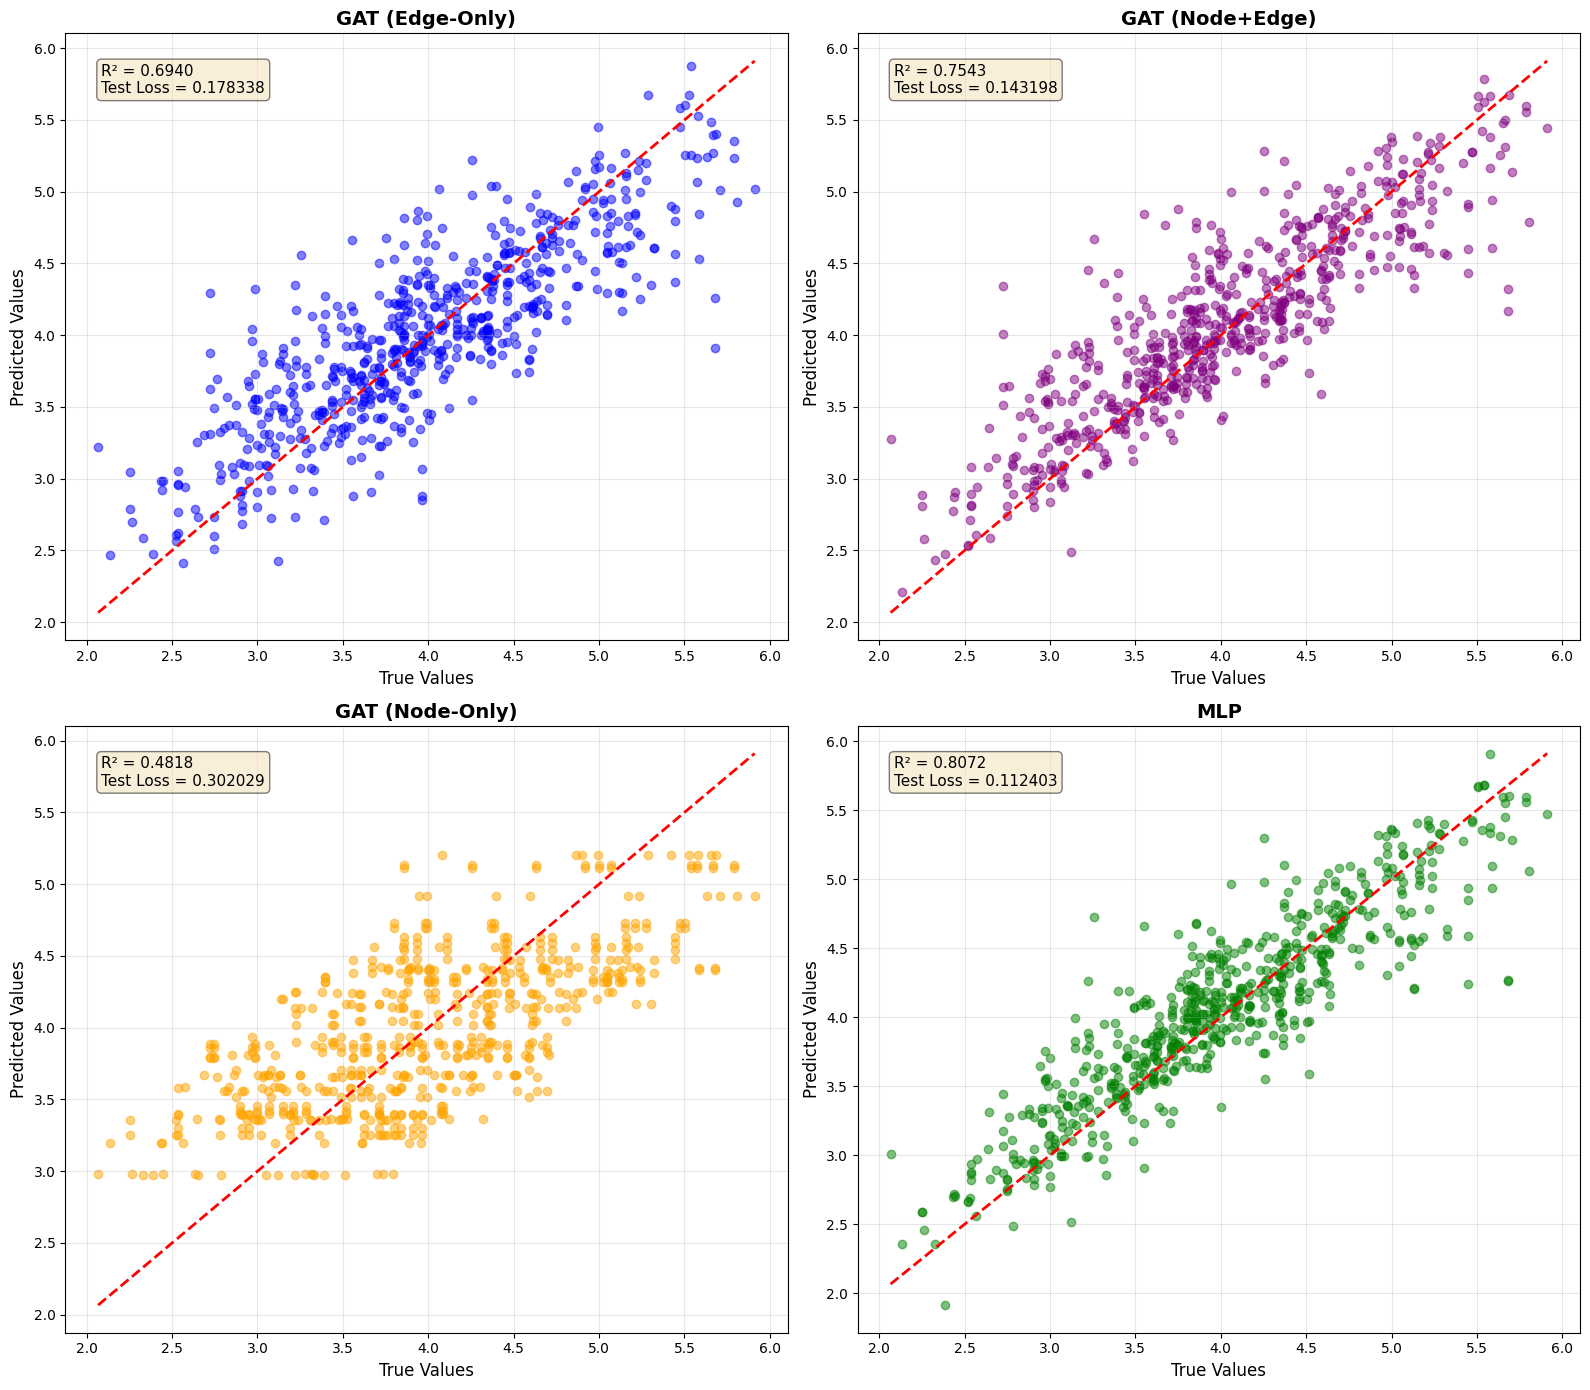

Model                                  R²    Test Loss
GAT (Edge-Only)                    0.6940     0.178338
GAT (Node+Edge)                    0.7543     0.143198
GAT (Node-Only)                    0.4818     0.302029
MLP                                0.8072     0.112403

Best Model: MLP (Test Loss: 0.112403)


In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def get_predictions(model, graphs, use_edge_feat=False):
    """Get predictions from a model."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for g in graphs:
            if use_edge_feat:
                pred = model(g, g.ndata['feat'], g.edata['feat'])
            else:
                pred = model(g, g.ndata['feat'])
            preds.extend(pred.cpu().numpy())
            labels.extend(g.ndata['label'].cpu().numpy())
    return np.array(preds), np.array(labels)

# Get predictions from all models
edge_only_preds, labels = get_predictions(gat_edge_only, test_graphs, use_edge_feat=True)
node_edge_preds, _ = get_predictions(gat_node_edge, test_graphs, use_edge_feat=True)
node_only_preds, _ = get_predictions(gat_node_only, test_graphs, use_edge_feat=False)
mlp_preds, _ = get_predictions(mlp_model, test_graphs, use_edge_feat=False)

# Plot comparison - 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

models_data = [
    (edge_only_preds, 'GAT (Edge-Only)', test_loss_edge_only, 'blue'),
    (node_edge_preds, 'GAT (Node+Edge)', test_loss_node_edge, 'purple'),
    (node_only_preds, 'GAT (Node-Only)', test_loss_node_only, 'orange'),
    (mlp_preds, 'MLP', test_loss_mlp, 'green')
]

for ax, (preds, name, loss, color) in zip(axes, models_data):
    ax.scatter(labels, preds, alpha=0.5, color=color)
    ax.plot([labels.min(), labels.max()], [labels.min(), labels.max()], 'r--', lw=2)
    ax.set_xlabel('True Values', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    r2 = r2_score(labels, preds)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}\nTest Loss = {loss:.6f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print comparison table
print(f"{'='*70}")
print(f"{'Model':<30} {'R²':>10} {'Test Loss':>12}")
print(f"{'='*70}")
print(f"{'GAT (Edge-Only)':<30} {r2_score(labels, edge_only_preds):>10.4f} {test_loss_edge_only:>12.6f}")
print(f"{'GAT (Node+Edge)':<30} {r2_score(labels, node_edge_preds):>10.4f} {test_loss_node_edge:>12.6f}")
print(f"{'GAT (Node-Only)':<30} {r2_score(labels, node_only_preds):>10.4f} {test_loss_node_only:>12.6f}")
print(f"{'MLP':<30} {r2_score(labels, mlp_preds):>10.4f} {test_loss_mlp:>12.6f}")
print(f"{'='*70}")

# Find and highlight best model
all_losses = {
    'GAT (Edge-Only)': test_loss_edge_only,
    'GAT (Node+Edge)': test_loss_node_edge,
    'GAT (Node-Only)': test_loss_node_only,
    'MLP': test_loss_mlp
}
best_model = min(all_losses, key=all_losses.get)
print(f"\nBest Model: {best_model} (Test Loss: {all_losses[best_model]:.6f})")
print("="*70)